# EEG-Bench Results Analysis

This notebook analyzes benchmark results from EEG-Bench experiments.

**Features:**
- Load all experiment results from JSON files
- Data efficiency curves (accuracy vs. training data %)
- Model comparison tables and heatmaps
- BCI vs Clinical task analysis

## 1. Setup & Data Loading

In [1]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, cohen_kappa_score
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Task categorization
BCI_TASKS = ["left_right", "right_feet", "left_right_feet_tongue", "5_fingers"]
CLINICAL_TASKS = [
    "parkinsons", "schizophrenia", "mtbi", "ocd", "epilepsy",
    "abnormal", "sleep_stages", "seizure", "binary_artifact", "multiclass_artifact"
]

# Friendly names for display
TASK_DISPLAY_NAMES = {
    "left_right": "Left/Right Hand",
    "right_feet": "Right Hand/Feet",
    "left_right_feet_tongue": "4-Class MI",
    "5_fingers": "5 Fingers",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "epilepsy": "Epilepsy",
    "abnormal": "Abnormal EEG",
    "sleep_stages": "Sleep Stages",
    "seizure": "Seizure",
    "binary_artifact": "Artifact (Binary)",
    "multiclass_artifact": "Artifact (Multi)"
}

MODEL_DISPLAY_NAMES = {
    "LaBraMModel": "LaBraM",
    "BENDRModel": "BENDR",
    "NeuroGPTModel": "NeuroGPT",
    "REVEBenchmarkModel": "REVE",
    "REVEClinicalModel": "REVE",
    "EEGLeJEPABCIModel": "LeJEPA",
    "EEGLeJEPAClinicalModel": "LeJEPA",
    "CSPLDAModel": "CSP-LDA",
    "CSPSVMModel": "CSP-SVM",
    "BrainfeaturesLDAModel": "LDA",
    "BrainfeaturesSVMModel": "SVM",
    "REVEModel": "REVE"
}

In [2]:

from collections.abc import Sequence


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def compute_metrics(y_true, y_pred):
    """Compute classification metrics from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return {
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_macro": np.nan,
            "kappa": np.nan,
        }

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    metrics = {
        "accuracy": accuracy_score(y_true_arr, y_pred_arr),
        "balanced_accuracy": balanced_accuracy_score(y_true_arr, y_pred_arr),
        "f1_weighted": f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true_arr, y_pred_arr),
    }
    return metrics


def load_results(results_dir="results/raw"):
    """Load all results JSON files into a DataFrame."""
    records = []

    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(json_files)} result files")

    for filepath in json_files:
        try:
            with open(filepath) as f:
                data = json.load(f)

            task_name = data.get("task_name", "unknown")
            model_names = data.get("models_names", ["unknown"])
            percentage = data.get("data_percentage", 1.0)
            linear_probe = data.get("linear_probe", False)
            timestamp = data.get("timestamp", "")
            data_stats = data.get("data_stats", {})
            ckpt_id = data.get("checkpoint_id", {})
            step = None
            if ckpt_id:
                step = int(ckpt_id.split('step_')[-1])
                print(step)

            y_test = data.get("y_test", [[]])
            results = data.get("results", [[]])

            # Process each model's results
            for i, model_name in enumerate(model_names):
                try:
                    # Get predictions for this model (handle nested structure)
                    if i < len(results):
                        y_pred = results[i] if isinstance(results[i], list) else results
                        y_true = y_test[i] if i < len(y_test) and isinstance(y_test[i], list) else y_test
                    else:
                        y_pred = results[0] if results else []
                        y_true = y_test[0] if y_test else []

                    # Compute metrics
                    metrics = compute_metrics(y_true, y_pred)

                    # Clean up model name for display
                    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

                    record = {
                        "task": task_name,
                        "task_display": TASK_DISPLAY_NAMES.get(task_name, task_name),
                        "task_type": "BCI" if task_name in BCI_TASKS else "Clinical",
                        "model": model_name,
                        "model_display": display_name,
                        "percentage": percentage,
                        "linear_probe": linear_probe,
                        "timestamp": timestamp,
                        "total_samples": data_stats.get("total_samples", 0),
                        "file": os.path.basename(filepath),
                        "step": step,
                        **metrics
                    }
                    records.append(record)

                except Exception as e:
                    print(f"Warning: Error processing {filepath} model {model_name}: {e}")

        except Exception as e:
            print(f"Warning: Could not load {filepath}: {e}")

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiment results")
    return df


In [3]:
# Load results
df = load_results("results/raw")

if len(df) > 0:
    print(f"\nUnique tasks: {df['task'].nunique()}")
    print(f"Unique models: {df['model_display'].nunique()}")
    print(f"Data percentages: {sorted(df['percentage'].unique())}")
    print(f"\nTasks: {df['task'].unique().tolist()}")
    print(f"Models: {df['model_display'].unique().tolist()}")
else:
    print("No results found. Run experiments first with run_experiments.py")

Found 86 result files
Loaded 86 experiment results

Unique tasks: 14
Unique models: 3
Data percentages: [0.25, 0.5, 0.75, 1.0]

Tasks: ['ocd_clinical', 'epilepsy_clinical', 'abnormal_clinical', 'mtbi_clinical', 'Left Hand vs Right Hand MI', 'multiclass_artifact_clinical', 'Five Fingers MI', 'binary_artifact_clinical', 'parkinsons_clinical', 'Left Hand vs Right Hand vs Feet vs Tongue MI', 'schizophrenia_clinical', 'Right Hand vs Feet MI', 'seizure_clinical', 'sleep_stages_clinical']
Models: ['LUNAModel', 'LaBraM', 'REVE']


In [ ]:
df.to_csv("results/baseline_results.csv")

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,total_samples,file,step,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa
0,ocd_clinical,ocd_clinical,Clinical,LUNAModel,LUNAModel,1.00,False,20260126_093459,35,ocd_clinical_LUNAModel_20260126_093459.json,None,0.818182,0.800000,0.808442,0.803571,0.620690
1,epilepsy_clinical,epilepsy_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260122_105745,826,epilepsy_clinical_LaBraMModel_pct50_LP_2026012...,None,0.686375,0.500000,0.558726,0.407012,0.000000
2,abnormal_clinical,abnormal_clinical,Clinical,REVEModel,REVE,1.00,False,20260126_021219,2717,abnormal_clinical_REVEModel_20260126_021219.json,None,0.463768,0.506032,0.307934,0.333551,0.011040
3,mtbi_clinical,mtbi_clinical,Clinical,REVEModel,REVE,1.00,False,20260125_193609,149,mtbi_clinical_REVEModel_20260125_193609.json,None,0.500000,0.602339,0.484615,0.497436,0.151515
4,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,Clinical,LaBraMModel,LaBraM,0.50,True,20260123_170659,13975,Left Hand vs Right Hand MI_LaBraMModel_pct50_L...,None,0.505732,0.507145,0.423185,0.423995,0.014249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,mtbi_clinical,mtbi_clinical,Clinical,LaBraMModel,LaBraM,1.00,True,20260121_153225,149,mtbi_clinical_LaBraMModel_LP_20260121_153225.json,None,0.678571,0.763158,0.682266,0.678161,0.416667
82,parkinsons_clinical,parkinsons_clinical,Clinical,LaBraMModel,LaBraM,0.25,True,20260123_010323,66,parkinsons_clinical_LaBraMModel_pct25_LP_20260...,None,0.627451,0.525696,0.568746,0.496623,0.059730
83,abnormal_clinical,abnormal_clinical,Clinical,REVEModel,REVE,1.00,False,20260125_225800,2717,abnormal_clinical_REVEModel_20260125_225800.json,None,0.463768,0.506032,0.307934,0.333551,0.011040
84,seizure_clinical,seizure_clinical,Clinical,LaBraMModel,LaBraM,0.75,True,20260123_103414,394,seizure_clinical_LaBraMModel_pct75_LP_20260123...,None,0.995126,0.503417,0.994494,0.504219,0.008604


In [5]:
# Preview data
if len(df) > 0:
    display(df.head(10))

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,total_samples,file,step,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa
0,ocd_clinical,ocd_clinical,Clinical,LUNAModel,LUNAModel,1.00,False,20260126_093459,35,ocd_clinical_LUNAModel_20260126_093459.json,None,0.818182,0.800000,0.808442,0.803571,0.620690
1,epilepsy_clinical,epilepsy_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260122_105745,826,epilepsy_clinical_LaBraMModel_pct50_LP_2026012...,None,0.686375,0.500000,0.558726,0.407012,0.000000
2,abnormal_clinical,abnormal_clinical,Clinical,REVEModel,REVE,1.00,False,20260126_021219,2717,abnormal_clinical_REVEModel_20260126_021219.json,None,0.463768,0.506032,0.307934,0.333551,0.011040
3,mtbi_clinical,mtbi_clinical,Clinical,REVEModel,REVE,1.00,False,20260125_193609,149,mtbi_clinical_REVEModel_20260125_193609.json,None,0.500000,0.602339,0.484615,0.497436,0.151515
4,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,Clinical,LaBraMModel,LaBraM,0.50,True,20260123_170659,13975,Left Hand vs Right Hand MI_LaBraMModel_pct50_L...,None,0.505732,0.507145,0.423185,0.423995,0.014249
5,multiclass_artifact_clinical,multiclass_artifact_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260122_175318,121,multiclass_artifact_clinical_LaBraMModel_pct50...,None,0.525069,0.400289,0.569113,0.326143,0.321204
6,abnormal_clinical,abnormal_clinical,Clinical,LaBraMModel,LaBraM,1.00,True,20260122_090129,2717,abnormal_clinical_LaBraMModel_LP_20260122_0901...,None,0.797101,0.798095,0.797444,0.796417,0.593178
7,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,Clinical,LaBraMModel,LaBraM,1.00,True,20260123_172040,27952,Left Hand vs Right Hand MI_LaBraMModel_LP_2026...,None,0.512530,0.512942,0.506537,0.506737,0.025862
8,Five Fingers MI,Five Fingers MI,Clinical,LaBraMModel,LaBraM,0.75,True,20260123_153011,12129,Five Fingers MI_LaBraMModel_pct75_LP_20260123_...,None,0.224855,0.218909,0.209139,0.205999,0.024719
9,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,0.25,True,20260123_105256,60,binary_artifact_clinical_LaBraMModel_pct25_LP_...,None,0.749361,0.747653,0.752096,0.739893,0.481419


## 2. Data Efficiency Curves

Plots showing how model performance changes with varying amounts of training data.

In [6]:
def plot_data_efficiency(df, task, metric="balanced_accuracy", figsize=(10, 6)):
    """Plot data efficiency curve for a single task."""
    task_df = df[df["task"] == task].copy()
    
    if len(task_df) == 0:
        print(f"No data for task: {task}")
        return
    
    plt.figure(figsize=figsize)
    
    models = task_df["model_display"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
        
        # Group by percentage and compute mean/std if multiple runs
        grouped = model_df.groupby("percentage")[metric].agg(["mean", "std"]).reset_index()
        
        plt.plot(grouped["percentage"] * 100, grouped["mean"],
                 marker='o', label=model, color=color, linewidth=2, markersize=8)
        
        # Add error bars if std available
        if grouped["std"].notna().any():
            plt.fill_between(grouped["percentage"] * 100,
                           grouped["mean"] - grouped["std"],
                           grouped["mean"] + grouped["std"],
                           alpha=0.2, color=color)
    
    task_display = TASK_DISPLAY_NAMES.get(task, task)
    plt.xlabel("Training Data (%)", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"Data Efficiency: {task_display}", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 105)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_all_efficiency_curves(df, metric="balanced_accuracy", tasks=None):
    """Plot data efficiency curves for all tasks."""
    if tasks is None:
        tasks = df["task"].unique()
    
    for task in tasks:
        plot_data_efficiency(df, task, metric)

In [7]:
# # Plot efficiency curves for all tasks
# if len(df) > 0:
#     plot_all_efficiency_curves(df, metric="accuracy")

In [8]:
def plot_efficiency_grid(df, metric="balanced_accuracy", ncols=3):
    """Plot all efficiency curves in a grid layout."""
    tasks = df["task"].unique()
    nrows = int(np.ceil(len(tasks) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if len(tasks) > 1 else [axes]
    
    models = df["model_display"].unique()
    colors = {m: plt.cm.tab10(i/len(models)) for i, m in enumerate(models)}
    print(models)
    
    for idx, task in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df["task"] == task]
        
        for model in models:
            model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
            if len(model_df) > 0:
                print(f"Plotting {model} for task {task}")
                grouped = model_df.groupby("percentage")[metric].mean().reset_index()
                ax.plot(grouped["percentage"] * 100, grouped[metric],
                       marker='o', label=model, color=colors[model], linewidth=2)
        
        ax.set_title(TASK_DISPLAY_NAMES.get(task, task), fontsize=11)
        ax.set_xlabel("Training Data (%)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(tasks), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(5, len(models)),
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("results/efficiency_curves_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/efficiency_curves_grid.png")

['LUNAModel' 'LaBraM' 'REVE']
Plotting LUNAModel for task ocd_clinical
Plotting LaBraM for task ocd_clinical
Plotting REVE for task ocd_clinical
Plotting LUNAModel for task epilepsy_clinical
Plotting LaBraM for task epilepsy_clinical
Plotting LUNAModel for task abnormal_clinical
Plotting LaBraM for task abnormal_clinical
Plotting REVE for task abnormal_clinical
Plotting LUNAModel for task mtbi_clinical
Plotting LaBraM for task mtbi_clinical
Plotting REVE for task mtbi_clinical
Plotting LaBraM for task Left Hand vs Right Hand MI
Plotting LaBraM for task multiclass_artifact_clinical
Plotting LaBraM for task Five Fingers MI
Plotting LaBraM for task binary_artifact_clinical
Plotting LUNAModel for task parkinsons_clinical
Plotting LaBraM for task parkinsons_clinical
Plotting LaBraM for task Left Hand vs Right Hand vs Feet vs Tongue MI
Plotting LUNAModel for task schizophrenia_clinical
Plotting LaBraM for task schizophrenia_clinical
Plotting REVE for task schizophrenia_clinical
Plotting LaBr

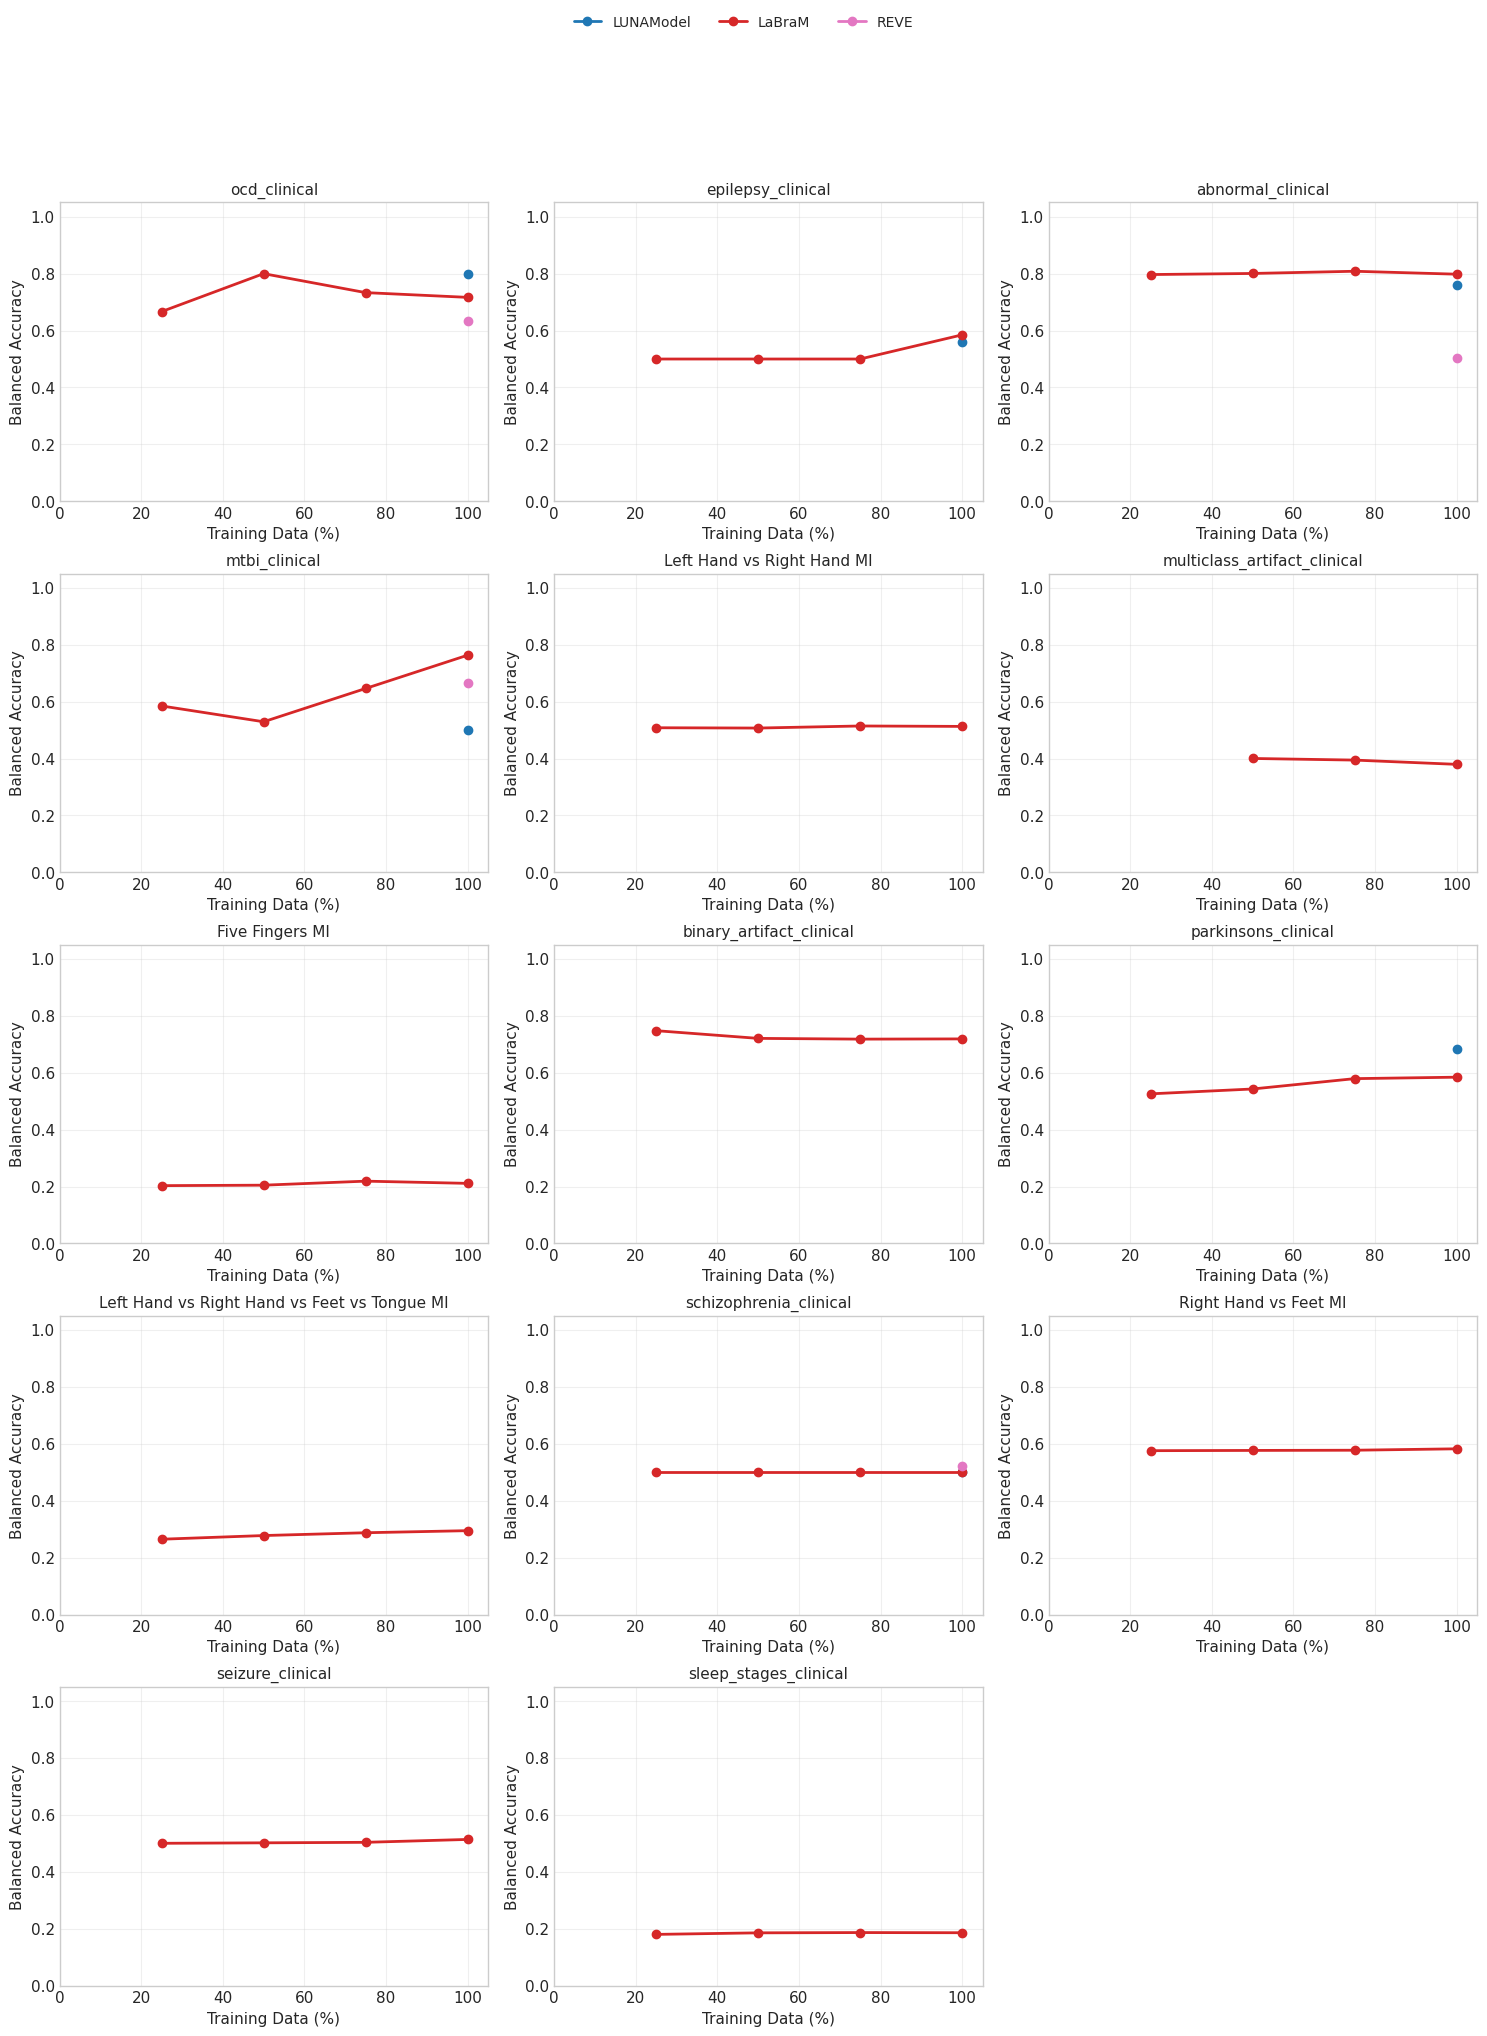

Saved to results/efficiency_curves_grid.png


In [9]:
# Plot grid view
if len(df) > 0 and df["task"].nunique() > 1:
    plot_efficiency_grid(df)

## 3. Model Comparison Tables

In [10]:
def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy"):
    """Create pivot table: models (rows) x tasks (columns)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        print(f"No data for percentage={percentage}")
        return None
    
    table = subset.pivot_table(
        values=metric,
        index="model_display",
        columns="task_display",
        aggfunc="mean"
    )
    
    # Add mean column
    table["Mean"] = table.mean(axis=1)
    
    # Sort by mean performance
    table = table.sort_values("Mean", ascending=False)
    
    return table.round(3)

In [11]:
# Display comparison table at 100% data
if len(df) > 0:
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        print("Model Comparison (100% training data, Balanced Accuracy):")
        display(table.style.background_gradient(cmap="RdYlGn", axis=None))

Model Comparison (100% training data, Balanced Accuracy):


task_display,Five Fingers MI,Left Hand vs Right Hand MI,Left Hand vs Right Hand vs Feet vs Tongue MI,Right Hand vs Feet MI,abnormal_clinical,binary_artifact_clinical,epilepsy_clinical,mtbi_clinical,multiclass_artifact_clinical,ocd_clinical,parkinsons_clinical,schizophrenia_clinical,seizure_clinical,sleep_stages_clinical,Mean
model_display,,,,,,,,,,,,,,,
LUNAModel,nan,nan,nan,nan,0.759000,nan,0.561000,0.500000,nan,0.800000,0.683000,0.500000,nan,nan,0.634000
REVE,nan,nan,nan,nan,0.505000,nan,nan,0.667000,nan,0.633000,nan,0.521000,nan,nan,0.582000
LaBraM,0.211000,0.513000,0.295000,0.582000,0.798000,0.719000,0.585000,0.763000,0.380000,0.717000,0.584000,0.500000,0.514000,0.186000,0.525000


In [12]:
def plot_comparison_heatmap(df, percentage=1.0, metric="accuracy", figsize=(14, 6)):
    """Plot heatmap of model performance across tasks."""
    table = model_comparison_table(df, percentage, metric)
    
    if table is None or len(table) == 0:
        return
    
    # Remove Mean column for heatmap
    plot_table = table.drop(columns=["Mean"], errors="ignore")
    
    plt.figure(figsize=figsize)
    sns.heatmap(plot_table, annot=True, cmap="RdYlGn", fmt=".2f",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": metric.replace("_", " ").title()})
    plt.title(f"Model {metric.replace('_', ' ').title()} by Task ({int(percentage*100)}% training data)",
              fontsize=14)
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"results/comparison_heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to results/comparison_heatmap_{metric}.png")

/raid/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


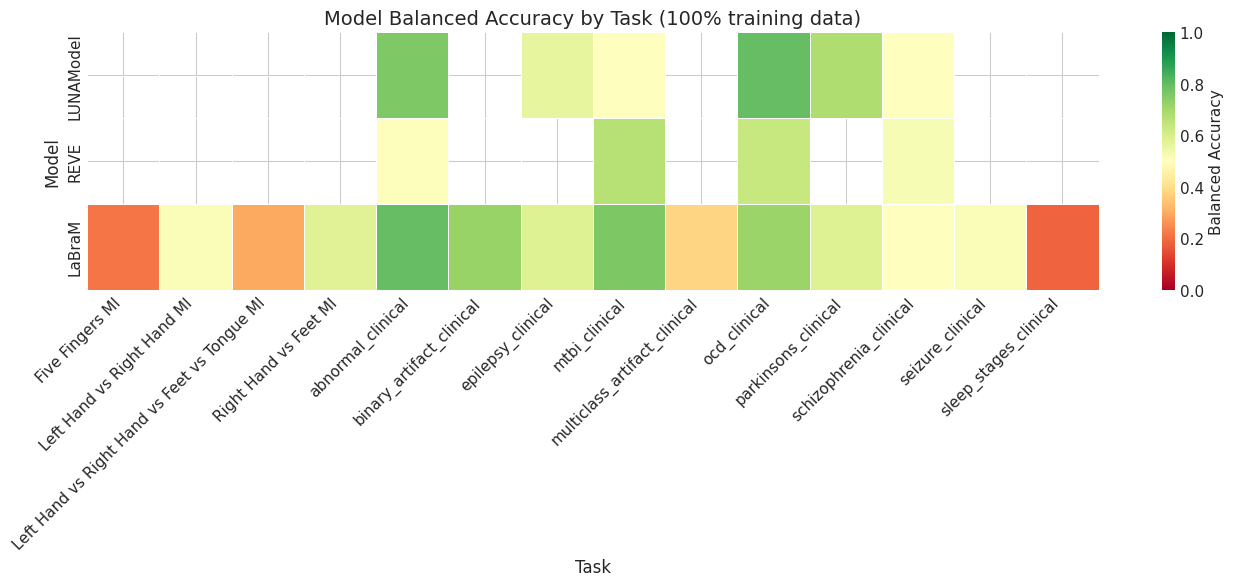

Saved to results/comparison_heatmap_balanced_accuracy.png


In [13]:
# Plot heatmap
if len(df) > 0:
    plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy")

## 4. Summary Statistics

In [14]:
def best_model_per_task(df, percentage=1.0, metric="accuracy"):
    """Find the best performing model for each task."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Group and find best
    idx = subset.groupby("task")[metric].idxmax()
    best = subset.loc[idx][["task", "task_display", "model_display", metric]].copy()
    best = best.rename(columns={metric: f"best_{metric}"})
    best = best.sort_values("task_display")
    
    return best

In [15]:
# Best model per task
if len(df) > 0:
    best = best_model_per_task(df)
    if best is not None:
        print("Best Model per Task (100% training data)")
        display(best)

Best Model per Task (100% training data)


,task,task_display,model_display,best_accuracy
28,Five Fingers MI,Five Fingers MI,LaBraM,0.207478
7,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LaBraM,0.512530
45,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LaBraM,0.294780
32,Right Hand vs Feet MI,Right Hand vs Feet MI,LaBraM,0.564802
6,abnormal_clinical,abnormal_clinical,LaBraM,0.797101
34,binary_artifact_clinical,binary_artifact_clinical,LaBraM,0.704803
71,epilepsy_clinical,epilepsy_clinical,LaBraM,0.732648
19,mtbi_clinical,mtbi_clinical,REVE,0.714286
42,multiclass_artifact_clinical,multiclass_artifact_clinical,LaBraM,0.503553
0,ocd_clinical,ocd_clinical,LUNAModel,0.818182


In [16]:
def compute_model_rankings(df, percentage=1.0, metric="accuracy"):
    """Compute average rank of each model across tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Compute rank per task (1 = best)
    subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
    # Average rank per model
    rankings = subset.groupby("model_display").agg({
        "rank": "mean",
        metric: "mean"
    }).round(2)
    
    rankings = rankings.sort_values("rank")
    rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
    return rankings

In [17]:
# Model rankings
if len(df) > 0:
    rankings = compute_model_rankings(df)
    if rankings is not None:
        print("Model Rankings (lower rank = better)")
        display(rankings)

Model Rankings (lower rank = better)


,Avg Rank,Avg Accuracy
model_display,,
LaBraM,1.61,0.58
LUNAModel,2.42,0.70
REVE,5.24,0.56


## 5. BCI vs Clinical Comparison

In [18]:
def plot_bci_vs_clinical(df, percentage=1.0, metric="accuracy"):
    """Compare model performance on BCI vs Clinical tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return
    
    # Group by model and task type
    comparison = subset.groupby(["model_display", "task_type"])[metric].mean().unstack()
    comparison = comparison.sort_values("BCI", ascending=False) if "BCI" in comparison.columns else comparison
    
    # Plot
    ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"BCI vs Clinical Performance ({int(percentage*100)}% training data)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Task Type", fontsize=10)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/bci_vs_clinical.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/bci_vs_clinical.png")

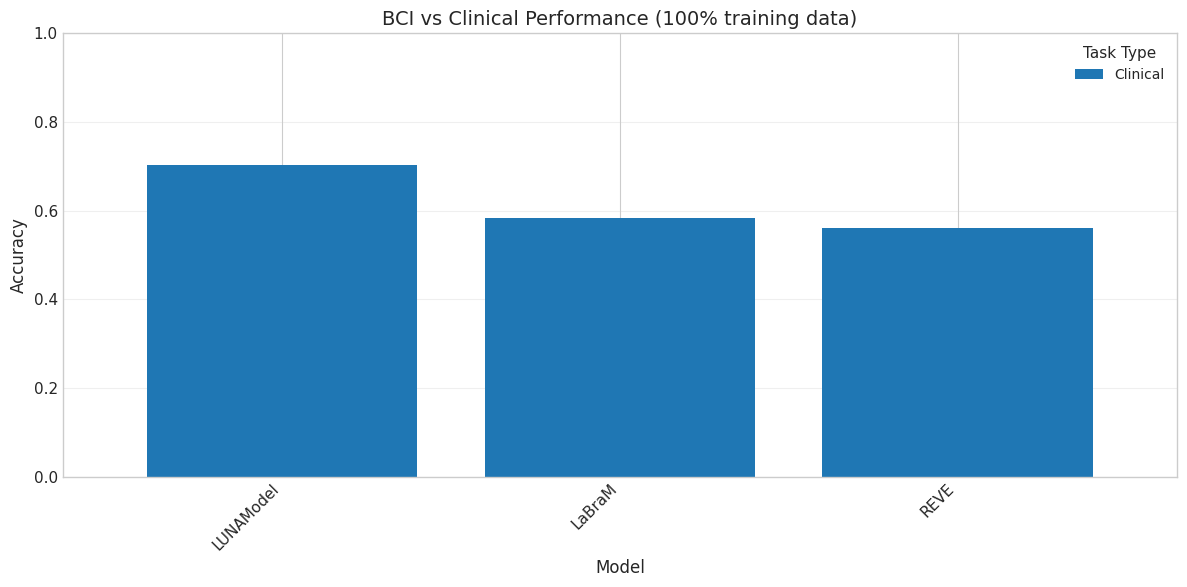

Saved to results/bci_vs_clinical.png


In [19]:
# BCI vs Clinical comparison
if len(df) > 0:
    plot_bci_vs_clinical(df)

## 6. Export Results

In [20]:
# Export full results to CSV
if len(df) > 0:
    output_path = "results/analysis_summary.csv"
    df.to_csv(output_path, index=False)
    print(f"Exported results to {output_path}")
    
    # Also export comparison table
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        table.to_csv("results/model_comparison_table.csv")
        print("Exported comparison table to results/model_comparison_table.csv")

Exported results to results/analysis_summary.csv
Exported comparison table to results/model_comparison_table.csv


## 7. Custom Analysis

Use the cells below for your own analysis.

In [ ]:
# Example: Filter and analyze specific subset
# df_lejepa = df[df["model_display"] == "LeJEPA"]
# df_bci = df[df["task_type"] == "BCI"]
# df_low_data = df[df["percentage"] <= 0.1]

In [ ]:
# Example: Compare linear probe vs full fine-tuning (if both available)
# if "linear_probe" in df.columns and df["linear_probe"].nunique() > 1:
#     lp_comparison = df.groupby(["model_display", "linear_probe"])["accuracy"].mean().unstack()
#     display(lp_comparison)